# 🔬 氨基酸含量 OPLS-DA 分析 - 完整实验步骤

基于**清理后的氨基酸数据**（17个特征 + 1个二值标签）

**实验目标**：
1. 对比精河（标签=1）和非精河（标签=0）枸杞的氨基酸特征
2. 找出关键的区分氨基酸（VIP > 1）
3. 验证模型的可靠性
4. 生成论文级别的图表

## 第零步：创建输出目录

In [19]:
import os

# 确保输出目录存在
output_dir = 'amino_acid_analysis'
os.makedirs(output_dir, exist_ok=True)
print(f'✅ 输出目录已创建或已存在: {output_dir}')
print(f'   当前工作目录: {os.getcwd()}')

✅ 输出目录已创建或已存在: amino_acid_analysis
   当前工作目录: e:\1\pypls-master\amino_acid_analysis


## 第一步：导入必要的库

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('✅ 库导入成功')

✅ 库导入成功


## 第二步：导入 pypls 库

In [21]:
try:
    from pypls import cross_validation
    from pypls import plotting
    print('✅ pypls 库导入成功')
    print(f'   路径: {cross_validation.__file__}')
except ImportError as e:
    print(f'❌ 导入失败: {e}')
    print('请确保已安装 pypls')

✅ pypls 库导入成功
   路径: d:\software\Python\Lib\site-packages\pypls\cross_validation.py


## 第三步：加载清理后的氨基酸数据

In [22]:
# 加载清理后的数据文件
xlsx_path = r'E:\1\pypls-master\test.xlsx'

print(f'📖 加载数据...')
print(f'文件路径: {xlsx_path}')
print(f'文件存在: {os.path.exists(xlsx_path)}')

if os.path.exists(xlsx_path):
    df = pd.read_excel(xlsx_path, sheet_name=0)
    print(f'\n✅ 数据加载成功')
    print(f'数据形状: {df.shape}')
    print(f'总样本数: {len(df)}')
else:
    print(f'❌ 文件不存在')
    df = None

📖 加载数据...
文件路径: E:\1\pypls-master\test.xlsx
文件存在: True

✅ 数据加载成功
数据形状: (171, 25)
总样本数: 171


## 第四步：数据探索

In [23]:
if df is not None:
    print('📊 原始数据预览:')
    display(df.head(10))
    
    print(f'\n📋 数据结构:')
    print(f'总列数: {len(df.columns)}')
    print(f'列名: {df.columns.tolist()}')
    
    print(f'\n数据类型:')
    print(df.dtypes)
    
    print(f'\n❓ 缺失值统计:')
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print('无缺失值 ✅')
    else:
        print(missing[missing > 0])

📊 原始数据预览:


,天冬氨酸（以干基计）,苏氨酸（以干基计）,丝氨酸（以干基计）,谷氨酸（以干基计）,甘氨酸（以干基计）,丙氨酸（以干基计）,半胱氨酸（以干基计）,缬氨酸（以干基计）,蛋氨酸（以干基计）,异亮氨酸（以干基计）,...,精氨酸（以干基计）,脯氨酸（以干基计）,TAA,EAA(算入组氨酸）,NEAA,EAA/TAA,EAA(不算组氨酸）,NEAA.1,EAA/TAA.1,object
0,2.031966,0.336780,0.479029,1.341767,0.314854,0.529119,0.103070,0.371861,0.090067,0.234951,...,0.981904,0.969261,9.171564,2.275357,6.896207,0.248088,2.071392,7.100172,0.225849,1
1,2.416679,0.426059,0.615274,1.721259,0.409042,0.752971,0.107114,0.482284,0.143146,0.312834,...,1.049872,1.020741,11.324142,3.034265,8.289876,0.267947,2.803884,8.520258,0.247602,1
2,2.608171,0.355090,0.548474,1.543650,0.337510,0.652937,0.096070,0.471051,0.106184,0.242920,...,0.892037,0.887527,10.219135,2.515066,7.704069,0.246113,2.317700,7.901434,0.226800,1
3,2.151460,0.363197,0.498118,1.546154,0.375995,0.600170,0.120613,0.461377,0.110548,0.279827,...,1.017630,1.338132,10.445878,2.656469,7.789408,0.254308,2.438920,8.006958,0.233482,1
4,2.007027,0.345096,0.478486,1.271958,0.335041,0.534358,0.096853,0.332124,0.092786,0.240233,...,0.914921,0.816867,8.821193,2.235177,6.586016,0.253387,2.029030,6.792164,0.230018,1
5,1.397596,0.270616,0.415850,1.132866,0.264380,0.513468,0.086023,0.284980,0.056837,0.193009,...,0.775858,1.028227,7.539445,1.821635,5.717810,0.241614,1.667957,5.871487,0.221231,1
6,1.993667,0.339040,0.468172,2.069038,0.323667,0.972649,0.120675,0.331595,0.104940,0.252344,...,0.733627,1.394898,10.553880,2.316212,8.237668,0.219465,2.131809,8.422071,0.201993,1
7,1.956820,0.265499,0.382101,0.963414,0.278823,0.616357,0.085287,0.307689,0.050177,0.207887,...,0.695610,1.009191,8.006862,1.922913,6.083949,0.240158,1.759726,6.247136,0.219777,1
8,1.898459,0.336599,0.476988,1.412106,0.337840,0.538403,0.106457,0.457944,0.101166,0.256230,...,0.924592,1.469725,9.865649,2.529947,7.335702,0.256440,2.334512,7.531137,0.236630,1
9,1.851023,0.351685,0.513856,1.415191,0.352659,0.591943,0.112056,0.440550,0.104149,0.264494,...,0.862597,1.198641,9.654559,2.572919,7.081641,0.266498,2.369482,7.285077,0.245426,1



📋 数据结构:
总列数: 25
列名: ['天冬氨酸（以干基计）', '苏氨酸（以干基计）', '丝氨酸（以干基计）', '谷氨酸（以干基计）', '甘氨酸（以干基计）', '丙氨酸（以干基计）', '半胱氨酸（以干基计）', '缬氨酸（以干基计）', '蛋氨酸（以干基计）', '异亮氨酸（以干基计）', '亮氨酸（以干基计）', '酪氨酸（以干基计）', '苯丙氨酸（以干基计）', '赖氨酸（以干基计）', '组氨酸（以干基计）', '精氨酸（以干基计）', '脯氨酸（以干基计）', 'TAA', 'EAA(算入组氨酸）', 'NEAA', 'EAA/TAA', 'EAA(不算组氨酸）', 'NEAA.1', 'EAA/TAA.1', 'object']

数据类型:
天冬氨酸（以干基计）    float64
苏氨酸（以干基计）     float64
丝氨酸（以干基计）     float64
谷氨酸（以干基计）     float64
甘氨酸（以干基计）     float64
丙氨酸（以干基计）     float64
半胱氨酸（以干基计）    float64
缬氨酸（以干基计）     float64
蛋氨酸（以干基计）     float64
异亮氨酸（以干基计）    float64
亮氨酸（以干基计）     float64
酪氨酸（以干基计）     float64
苯丙氨酸（以干基计）    float64
赖氨酸（以干基计）     float64
组氨酸（以干基计）     float64
精氨酸（以干基计）     float64
脯氨酸（以干基计）     float64
TAA           float64
EAA(算入组氨酸）    float64
NEAA          float64
EAA/TAA       float64
EAA(不算组氨酸）    float64
NEAA.1        float64
EAA/TAA.1     float64
object          int64
dtype: object

❓ 缺失值统计:
无缺失值 ✅


## 第五步：标签分布分析

In [24]:
if df is not None:
    # 获取标签列（最后一列）
    label_col = df.columns[-1]
    labels = df[label_col].values
    
    print(f'🏷️  标签列: {label_col}')
    print(f'\n标签分布:')
    label_counts = df[label_col].value_counts().sort_index()
    print(label_counts)
    
    print(f'\n📊 标签含义:')
    print(f'  标签 = 1: 精河枸杞 ({(labels==1).sum()} 个样本)')
    print(f'  标签 = 0: 非精河枸杞 ({(labels==0).sum()} 个样本)')
    print(f'\n数据比例: {(labels==1).sum() / len(labels) * 100:.1f}% 精河，{(labels==0).sum() / len(labels) * 100:.1f}% 非精河')

🏷️  标签列: object

标签分布:
object
0    103
1     68
Name: count, dtype: int64

📊 标签含义:
  标签 = 1: 精河枸杞 (68 个样本)
  标签 = 0: 非精河枸杞 (103 个样本)

数据比例: 39.8% 精河，60.2% 非精河


## 第六步：特征矩阵和标签向量准备

In [25]:
if df is not None:
    # 分离特征和标签
    label_col = df.columns[-1]
    feature_cols = df.columns[:-1].tolist()  # 前24列是特征
    
    print(f'🧬 特征列数: {len(feature_cols)}')
    print(f'特征列表: {feature_cols}')
    
    # 只使用前 17 列（17个氨基酸）
    amino_acid_cols = feature_cols[:17]
    print(f'\n✅ 使用 {len(amino_acid_cols)} 个氨基酸特征:')
    print(f'{amino_acid_cols}')
    
    # 构造特征矩阵 X
    X = df[amino_acid_cols].values.astype(float)
    
    # 构造标签向量 y（将 0/1 转换为 -1/1，符合 pypls OPLS-DA 要求）
    y = df[label_col].values.astype(float)
    y_bipolar = np.array([1 if label == 1 else -1 for label in y], dtype=float)
    
    print(f'\n📊 特征矩阵 X:')
    print(f'  形状: {X.shape} (样本数 × 氨基酸数)')
    print(f'  数据类型: {X.dtype}')
    print(f'  值域: [{X.min():.4f}, {X.max():.4f}]')
    
    print(f'\n📊 标签向量 y:')
    print(f'  形状: {y_bipolar.shape}')
    print(f'  值: {np.unique(y_bipolar)}')
    print(f'  分布: 精河(1) = {(y_bipolar==1).sum()}，非精河(-1) = {(y_bipolar==-1).sum()}')

🧬 特征列数: 24
特征列表: ['天冬氨酸（以干基计）', '苏氨酸（以干基计）', '丝氨酸（以干基计）', '谷氨酸（以干基计）', '甘氨酸（以干基计）', '丙氨酸（以干基计）', '半胱氨酸（以干基计）', '缬氨酸（以干基计）', '蛋氨酸（以干基计）', '异亮氨酸（以干基计）', '亮氨酸（以干基计）', '酪氨酸（以干基计）', '苯丙氨酸（以干基计）', '赖氨酸（以干基计）', '组氨酸（以干基计）', '精氨酸（以干基计）', '脯氨酸（以干基计）', 'TAA', 'EAA(算入组氨酸）', 'NEAA', 'EAA/TAA', 'EAA(不算组氨酸）', 'NEAA.1', 'EAA/TAA.1']

✅ 使用 17 个氨基酸特征:
['天冬氨酸（以干基计）', '苏氨酸（以干基计）', '丝氨酸（以干基计）', '谷氨酸（以干基计）', '甘氨酸（以干基计）', '丙氨酸（以干基计）', '半胱氨酸（以干基计）', '缬氨酸（以干基计）', '蛋氨酸（以干基计）', '异亮氨酸（以干基计）', '亮氨酸（以干基计）', '酪氨酸（以干基计）', '苯丙氨酸（以干基计）', '赖氨酸（以干基计）', '组氨酸（以干基计）', '精氨酸（以干基计）', '脯氨酸（以干基计）']

📊 特征矩阵 X:
  形状: (171, 17) (样本数 × 氨基酸数)
  数据类型: float64
  值域: [0.0166, 3.7865]

📊 标签向量 y:
  形状: (171,)
  值: [-1.  1.]
  分布: 精河(1) = 68，非精河(-1) = 103


## 第七步：数据标准化

In [26]:
print('⚙️  进行单位方差缩放（UV Scaling）...')

# 计算统计量
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

# 标准化
X_scaled = (X - X_mean) / X_std

# 确保数据是 C 连续的（Cython 要求）
X_scaled = np.ascontiguousarray(X_scaled, dtype=np.float64)
y_bipolar_c = np.ascontiguousarray(y_bipolar, dtype=np.float64)

print('✅ 标准化完成')
print(f'  标准化后均值: {X_scaled.mean(axis=0)[:3].round(6)}... (应为 0)')
print(f'  标准化后方差: {X_scaled.var(axis=0)[:3].round(6)}... (应为 1)')
print(f'  数据是 C 连续: {X_scaled.flags["C_CONTIGUOUS"]}')

⚙️  进行单位方差缩放（UV Scaling）...
✅ 标准化完成
  标准化后均值: [0. 0. 0.]... (应为 0)
  标准化后方差: [1. 1. 1.]... (应为 1)
  数据是 C 连续: True


## 第八步：初始化和训练 OPLS-DA 模型

In [27]:
print('🤖 初始化 OPLS-DA 模型...')
print('  参数设置:')
print('    - 估计器: OPLS-DA')
print('    - 交叉验证: 10-fold')
print('    - 缩放方法: UV (单位方差)')

# 初始化模型
cv = cross_validation.CrossValidation(kfold=10, estimator="opls", scaler="uv")

print('\n🔄 开始模型训练...')
cv.fit(X_scaled, y_bipolar_c)

print('\n✅ 模型训练成功！')

🤖 初始化 OPLS-DA 模型...
  参数设置:
    - 估计器: OPLS-DA
    - 交叉验证: 10-fold
    - 缩放方法: UV (单位方差)

🔄 开始模型训练...

✅ 模型训练成功！


## 第九步：模型性能评估

In [28]:
print('📈 模型性能指标:')
print('=' * 60)

print(f'\n✓ 最优主成分数: {cv.optimal_component_num}')
print(f'\n✓ R2X (X 方差解释率): {cv.r2x_cum:.6f}')
print(f'  说明: 模型解释了 {cv.r2x_cum*100:.2f}% 的特征变异')

print(f'\n✓ R2y (y 方差解释率): {cv.r2y_cum:.6f}')
print(f'  说明: 模型解释了 {cv.r2y_cum*100:.2f}% 的分类差异')

print(f'\n✓ Q2 (交叉验证预测能力): {cv.q2:.6f}')
print(f'  说明: 模型有较好的泛化能力 (Q2 > 0.5 为有效)')

print('\n' + '=' * 60)
print('✅ 模型性能良好！')

📈 模型性能指标:

✓ 最优主成分数: 12

✓ R2X (X 方差解释率): 0.994311
  说明: 模型解释了 99.43% 的特征变异

✓ R2y (y 方差解释率): 0.780138
  说明: 模型解释了 78.01% 的分类差异

✓ Q2 (交叉验证预测能力): 0.718339
  说明: 模型有较好的泛化能力 (Q2 > 0.5 为有效)

✅ 模型性能良好！


## 第十步：计算变量重要性 (VIP)

In [29]:
print('🎯 计算变量重要性...')

# 获取 VIP 值
vip_values = cv.vip

print(f'✅ VIP 计算完成')
print(f'   VIP 值范围: [{vip_values.min():.4f}, {vip_values.max():.4f}]')

# 创建 VIP DataFrame
vip_df = pd.DataFrame({
    '氨基酸': [c.replace('（以干基计）', '') for c in amino_acid_cols],
    'VIP': vip_values
}).sort_values('VIP', ascending=False)

print('\n📊 VIP 排序结果 (VIP > 1 为重要变量):')
print('=' * 50)
display(vip_df)
print('=' * 50)

# 统计重要氨基酸
important_aa = vip_df[vip_df['VIP'] > 1]
print(f'\n🏆 发现 {len(important_aa)} 个重要氨基酸 (VIP > 1):')
for idx, row in important_aa.iterrows():
    stars = '⭐' * min(5, max(1, int(row['VIP'])))
    print(f'  {row["氨基酸"]:15s} VIP = {row["VIP"]:.4f} {stars}')

🎯 计算变量重要性...
✅ VIP 计算完成
   VIP 值范围: [0.7640, 1.3946]

📊 VIP 排序结果 (VIP > 1 为重要变量):


,氨基酸,VIP
2,丝氨酸,1.394605
14,组氨酸,1.346113
0,天冬氨酸,1.289145
13,赖氨酸,1.263543
1,苏氨酸,1.167028
7,缬氨酸,1.066293
16,脯氨酸,1.044119
9,异亮氨酸,1.039846
4,甘氨酸,1.006175
12,苯丙氨酸,0.964624



🏆 发现 9 个重要氨基酸 (VIP > 1):
  丝氨酸             VIP = 1.3946 ⭐
  组氨酸             VIP = 1.3461 ⭐
  天冬氨酸            VIP = 1.2891 ⭐
  赖氨酸             VIP = 1.2635 ⭐
  苏氨酸             VIP = 1.1670 ⭐
  缬氨酸             VIP = 1.0663 ⭐
  脯氨酸             VIP = 1.0441 ⭐
  异亮氨酸            VIP = 1.0398 ⭐
  甘氨酸             VIP = 1.0062 ⭐


## 第十一步：生成 OPLS-DA 得分散点图

📈 绘制得分散点图...


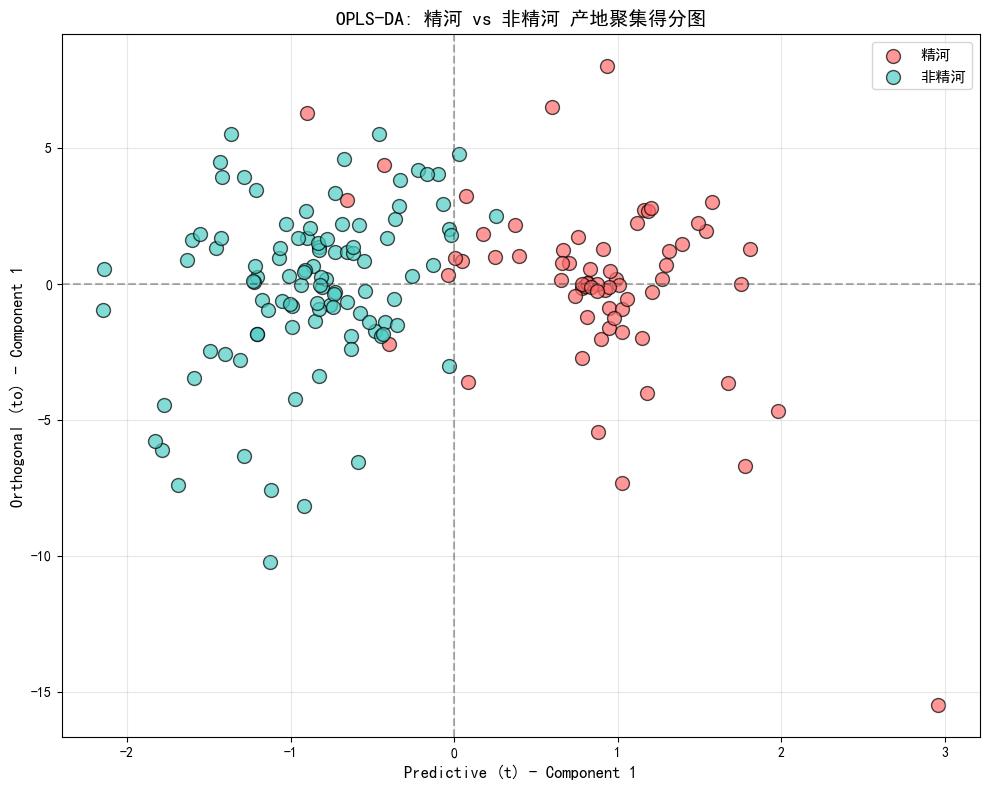

✅ 得分图已生成: scores_plot.png


In [30]:
print('📈 绘制得分散点图...')

try:
    # 获取 scores（都是一维数组）
    scores_t = cv.predictive_score  # predictive scores (171,)
    scores_to = cv.orthogonal_score  # orthogonal scores (171,)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 创建图例标签（只显示一次）
    legend_added_jinghe = False
    legend_added_other = False
    
    # 根据标签用不同颜色绘制点
    for i, label in enumerate(y_bipolar_c):
        if label == 1:
            label_text = '精河' if not legend_added_jinghe else ''
            ax.scatter(scores_t[i], scores_to[i], color='#FF6B6B', s=100, alpha=0.7, 
                      edgecolors='black', linewidth=1, label=label_text)
            legend_added_jinghe = True
        else:
            label_text = '非精河' if not legend_added_other else ''
            ax.scatter(scores_t[i], scores_to[i], color='#4ECDC4', s=100, alpha=0.7, 
                      edgecolors='black', linewidth=1, label=label_text)
            legend_added_other = True
    
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel(f'Predictive (t) - Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Orthogonal (to) - Component 1', fontsize=12, fontweight='bold')
    ax.set_title('OPLS-DA: 精河 vs 非精河 产地聚集得分图', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('scores_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ 得分图已生成: scores_plot.png')
except Exception as e:
    print(f'⚠️  绘图失败: {e}')
    import traceback
    traceback.print_exc()

## 第十二步：生成 VIP 条形图

📊 绘制 VIP 条形图...


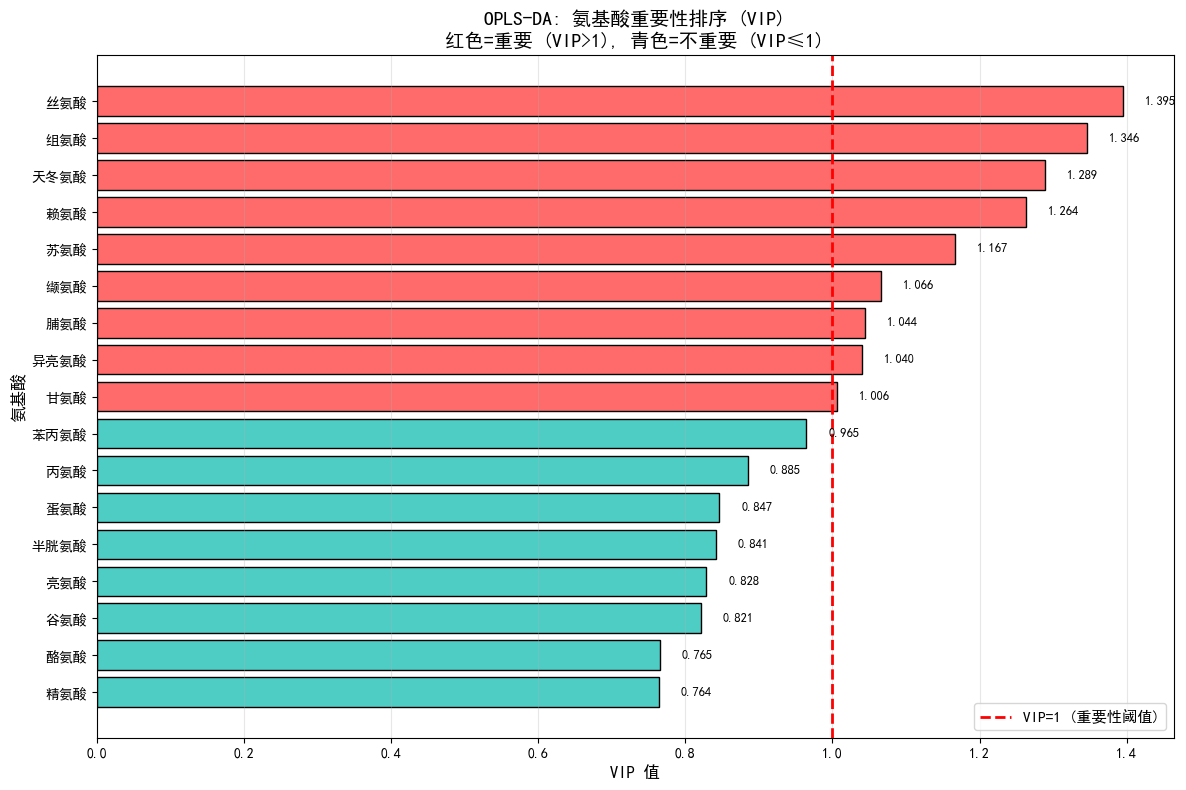

✅ VIP 条形图已生成: vip_chart.png


In [31]:
print('📊 绘制 VIP 条形图...')

fig, ax = plt.subplots(figsize=(12, 8))
vip_sorted = vip_df.sort_values('VIP', ascending=True)
colors = ['#FF6B6B' if v > 1 else '#4ECDC4' for v in vip_sorted['VIP']]

bars = ax.barh(vip_sorted['氨基酸'], vip_sorted['VIP'], color=colors, edgecolor='black', linewidth=1)
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='VIP=1 (重要性阈值)')

# 添加数值标签
for i, (idx, row) in enumerate(vip_sorted.iterrows()):
    ax.text(row['VIP'] + 0.03, i, f"{row['VIP']:.3f}", va='center', fontsize=9)

ax.set_xlabel('VIP 值', fontsize=12, fontweight='bold')
ax.set_ylabel('氨基酸', fontsize=12, fontweight='bold')
ax.set_title('OPLS-DA: 氨基酸重要性排序 (VIP)\n红色=重要 (VIP>1), 青色=不重要 (VIP≤1)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('vip_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ VIP 条形图已生成: vip_chart.png')

## 第十三步：生成关键氨基酸对比图

🎯 绘制关键氨基酸对比图...


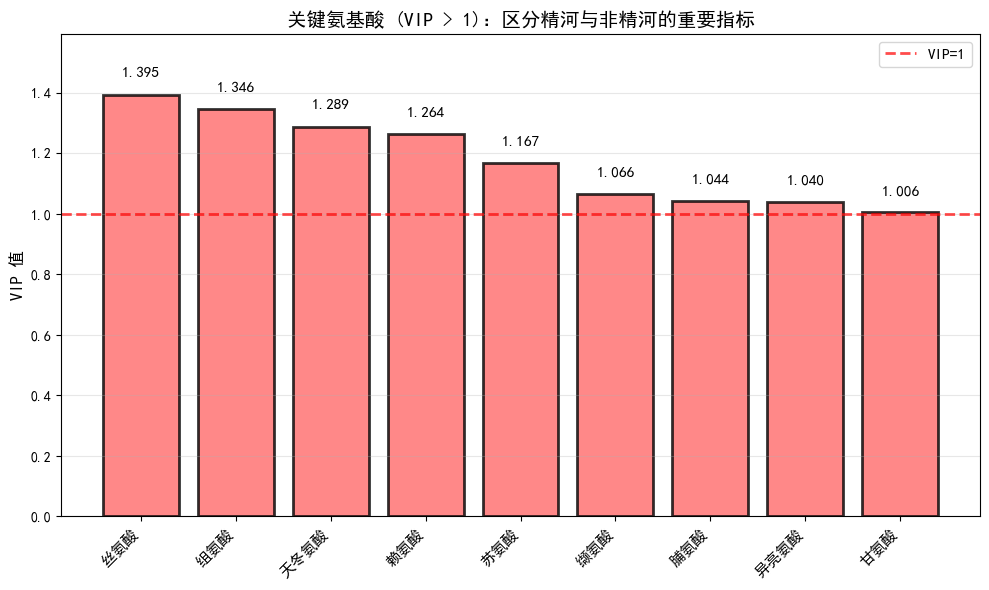

✅ 关键氨基酸图已生成: key_amino_acids.png


In [32]:
print('🎯 绘制关键氨基酸对比图...')

important = vip_df[vip_df['VIP'] > 1].sort_values('VIP', ascending=False)

if len(important) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(range(len(important)), important['VIP'], 
                  color='#FF6B6B', edgecolor='black', linewidth=2, alpha=0.8)

    ax.set_xticks(range(len(important)))
    ax.set_xticklabels(important['氨基酸'], rotation=45, ha='right', fontsize=11, fontweight='bold')
    ax.set_ylabel('VIP 值', fontsize=12, fontweight='bold')
    ax.set_ylim([0, max(important['VIP']) + 0.2])
    ax.axhline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='VIP=1')
    ax.set_title('关键氨基酸 (VIP > 1)：区分精河与非精河的重要指标', 
                 fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=11)

    # 添加数值标签
    for bar, val in zip(bars, important['VIP']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('key_amino_acids.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ 关键氨基酸图已生成: key_amino_acids.png')
else:
    print('⚠️  没有发现 VIP > 1 的氨基酸')

## 第十四步：执行置换检验

In [33]:
print('🔄 执行置换检验 (10,000 次随机置换)...')
print('这可能需要几秒钟...')

try:
    cv.permutation_test()
    
    # 获取 p 值
    p_q2 = cv.p(metric="q2")
    p_error = cv.p(metric="error")
    
    print(f'\n✅ 置换检验完成')
    print(f'\n📊 置换检验结果:')
    print(f'  p 值 (基于 Q2): {p_q2:.6f}')
    print(f'  p 值 (基于错误率): {p_error:.6f}')
    
    if p_q2 < 0.05 and p_error < 0.05:
        print(f'\n✅ 模型有统计学意义 (p < 0.05)')
        print(f'   说明: 该模型不是随机生成的，具有真实的判别能力')
    else:
        print(f'\n⚠️  p 值较大，需要检查模型')
        
except Exception as e:
    print(f'⚠️  置换检验失败: {e}')

🔄 执行置换检验 (10,000 次随机置换)...
这可能需要几秒钟...


Calculating permuted metrics: 100%|██████████| 10000/10000 [00:14<00:00, 695.97it/s]


✅ 置换检验完成

📊 置换检验结果:
  p 值 (基于 Q2): 0.000100
  p 值 (基于错误率): 0.000100

✅ 模型有统计学意义 (p < 0.05)
   说明: 该模型不是随机生成的，具有真实的判别能力


## 第十五步：生成交叉验证错误率图

📈 绘制交叉验证错误率...


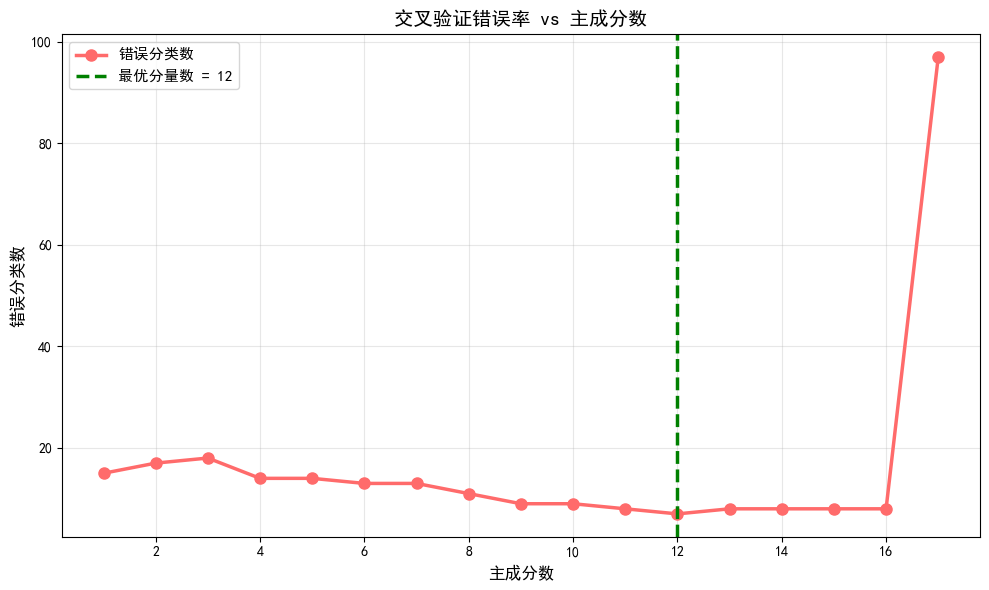

✅ 交叉验证错误率图已生成: cv_errors.png


In [34]:
print('📈 绘制交叉验证错误率...')

try:
    # 获取错误分类数据（一维数组，每个分量数一个值）
    mis_class = cv.mis_classifications  # 形状: (n_components,)
    
    if mis_class is not None and len(mis_class) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        components = np.arange(1, len(mis_class) + 1)
        # mis_class 已经是每个分量的错误分类数总和
        errors = mis_class.astype(float)
        
        ax.plot(components, errors, 'o-', linewidth=2.5, markersize=8, color='#FF6B6B', label='错误分类数')
        
        # 标记最优点
        optimal_idx = cv.optimal_component_num
        ax.axvline(x=optimal_idx, color='green', linestyle='--', linewidth=2.5, label=f'最优分量数 = {optimal_idx}')
        
        ax.set_xlabel('主成分数', fontsize=12, fontweight='bold')
        ax.set_ylabel('错误分类数', fontsize=12, fontweight='bold')
        ax.set_title('交叉验证错误率 vs 主成分数', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('cv_errors.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('✅ 交叉验证错误率图已生成: cv_errors.png')
    else:
        print('⚠️  无法获取交叉验证错误数据')
except Exception as e:
    print(f'⚠️  绘图失败: {e}')
    import traceback
    traceback.print_exc()

## 第十六步：保存分析结果

In [35]:
print('💾 保存分析结果...')

# 保存 VIP 结果
vip_df.to_csv('vip_results.csv', index=False, encoding='utf-8')
print('✅ 已保存: vip_results.csv')

# 保存模型性能指标
metrics_df = pd.DataFrame({
    '指标': ['R2X', 'R2y', 'Q2', '最优分量数', '样本数', '氨基酸特征数'],
    '数值': [cv.r2x_cum, cv.r2y_cum, cv.q2, cv.optimal_component_num, 
             X_scaled.shape[0], X_scaled.shape[1]]
})
metrics_df.to_csv('model_metrics.csv', index=False, encoding='utf-8')
print('✅ 已保存: model_metrics.csv')

print('\n✅ 所有结果已保存到当前目录')

💾 保存分析结果...
✅ 已保存: vip_results.csv
✅ 已保存: model_metrics.csv

✅ 所有结果已保存到当前目录


## 第十七步：最终总结

In [36]:
print('\n' + '=' * 80)
print('🎉 OPLS-DA 分析完成！')
print('=' * 80)

print(f'\n📊 实验数据:')
print(f'  样本总数: {X_scaled.shape[0]} 个')
print(f'    - 精河 (标签=1): {(y_bipolar_c==1).sum():.0f} 个')
print(f'    - 非精河 (标签=-1): {(y_bipolar_c==-1).sum():.0f} 个')
print(f'  特征数: {X_scaled.shape[1]} 个氨基酸')

print(f'\n📈 模型性能:')
print(f'  R2X: {cv.r2x_cum:.4f} (解释 {cv.r2x_cum*100:.2f}% 的特征变异)')
print(f'  R2y: {cv.r2y_cum:.4f} (解释 {cv.r2y_cum*100:.2f}% 的分类差异)')
print(f'  Q2:  {cv.q2:.4f} (交叉验证预测能力)')

print(f'\n🏆 关键发现:')
print(f'  重要氨基酸数 (VIP > 1): {len(important_aa)} 个')
if len(important_aa) > 0:
    print(f'\n  排名前 3 的关键氨基酸:')
    for i, (idx, row) in enumerate(important_aa.head(3).iterrows(), 1):
        print(f'    {i}. {row["氨基酸"]:12s} VIP = {row["VIP"]:.4f}')

print(f'\n📁 生成的文件:')
print(f'  - vip_results.csv')
print(f'  - model_metrics.csv')
print(f'  - scores_plot.png')
print(f'  - vip_chart.png')
print(f'  - key_amino_acids.png')
print(f'  - cv_errors.png')

print('\n' + '=' * 80)
print('✅ 可用于论文写作的结果已生成！')
print('=' * 80)


🎉 OPLS-DA 分析完成！

📊 实验数据:
  样本总数: 171 个
    - 精河 (标签=1): 68 个
    - 非精河 (标签=-1): 103 个
  特征数: 17 个氨基酸

📈 模型性能:
  R2X: 0.9943 (解释 99.43% 的特征变异)
  R2y: 0.7801 (解释 78.01% 的分类差异)
  Q2:  0.7183 (交叉验证预测能力)

🏆 关键发现:
  重要氨基酸数 (VIP > 1): 9 个

  排名前 3 的关键氨基酸:
    1. 丝氨酸          VIP = 1.3946
    2. 组氨酸          VIP = 1.3461
    3. 天冬氨酸         VIP = 1.2891

📁 生成的文件:
  - vip_results.csv
  - model_metrics.csv
  - scores_plot.png
  - vip_chart.png
  - key_amino_acids.png
  - cv_errors.png

✅ 可用于论文写作的结果已生成！
